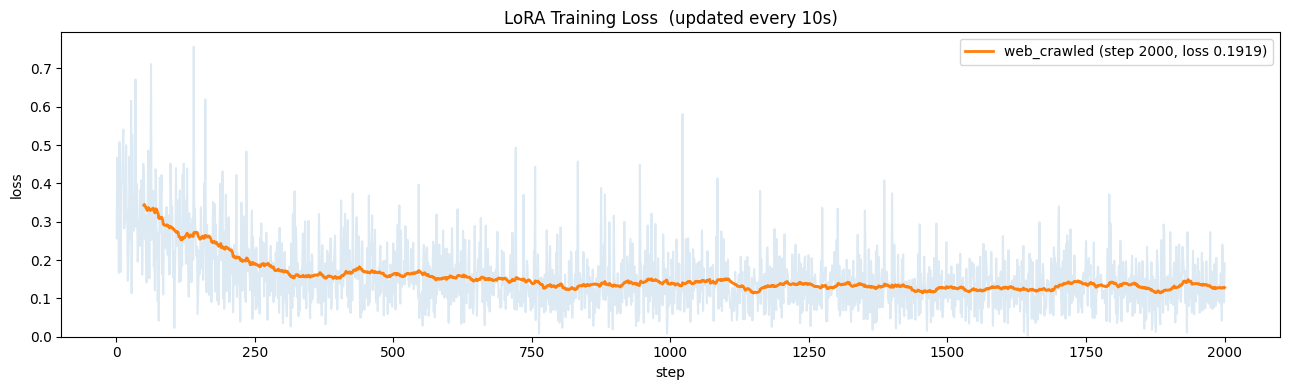

KeyboardInterrupt: 

In [1]:
import time
import os
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import clear_output

LOG_PATHS = {
    "web_crawled": "./sd_lora/loss_log.csv",
    # "real":        "./lora_experiments/dataset_training/real/rank8_alpha8/loss_log.csv",
    # "generated":   "./lora_experiments/dataset_training/generated/rank8_alpha8/loss_log.csv",
}
REFRESH_SEC = 10  # 갱신 주기 (초)

while True:
    clear_output(wait=True)
    fig, ax1 = plt.subplots(figsize=(13, 4))

    for label, log_path in LOG_PATHS.items():
        if not os.path.exists(log_path):
            print(f"{label}: 아직 로그 없음")
            continue
        df = pd.read_csv(log_path)
        if df.empty:
            continue
        df = df.drop_duplicates(subset="step", keep="last").sort_values("step")
        ax1.plot(df["step"], df["step_loss"], alpha=0.15)
        window = min(50, len(df))
        ax1.plot(df["step"], df["step_loss"].rolling(window).mean(),
                 linewidth=2, label=f"{label} (step {df['step'].iloc[-1]}, loss {df['step_loss'].iloc[-1]:.4f})")

    ax1.set_xlabel("step")
    ax1.set_ylabel("loss")
    ax1.set_ylim(bottom=0)
    ax1.legend(loc="upper right")
    plt.title(f"LoRA Training Loss  (updated every {REFRESH_SEC}s)")
    plt.tight_layout()
    plt.show()
    time.sleep(REFRESH_SEC)
